# Molecular representation ablation

## The question

This study compared domain adaptation on Graphormer embeddings. But in the QSAR baseline comparison
**RDKit descriptors were consistently better than Graphormer** (f_u 0.44 vs 0.28). So did the choice of representation
drive the results? Decompose what each representation actually contributes.

| Representation | Dimensions | Nature |
|---|---|---|
| `MorganFP` | 2048 | ECFP4 fingerprint — substructure patterns |
| `Mordred` | 1445 | physicochemical descriptors |
| `RDKit` | 203 | physicochemical descriptors (largely overlapping with Mordred) |
| `Graphormer` | 768 | graph embedding pretrained on PCQM4Mv2 |

## Design

- **Single** (4) — how far each representation goes on its own
- **Full** — all four representations (4464-d)
- **Full − X** — remove one at a time (leave-one-out). The drop from Full is that representation's **unique contribution**.
  If another representation carries the same information, removing it does not hurt.
- **MorganFP+Mordred** — the combination used by PKSmart

Models: XGBoost's RF mode and gradient boosting, target-only training, scaffold 5-fold × 3 seeds.
Hyperparameters are untuned conventional values, so read this only as a **relative comparison between representations**.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = r'..'
RES = os.path.join(ROOT, 'results', 'representation')
FIG = os.path.join(ROOT, 'results', 'figures')
os.makedirs(FIG, exist_ok=True)

PROPS = ['fu', 'clearance', 'half_life']
LABEL = {'fu': '$f_u$', 'clearance': 'CL', 'half_life': '$t_{1/2}$'}
COLOR = {'fu': '#1a7f37', 'clearance': '#0969da', 'half_life': '#cf222e'}
ALL4 = ['MorganFP', 'Mordred', 'RDKit', 'Graphormer']
SOLO, LOO = ALL4, [f'Full − {k}' for k in ALL4]
ORDER = SOLO + ['MorganFP+Mordred', 'Full'] + LOO
METRICS = [('r2', 'R²', True), ('r', 'Pearson r', True), ('rho', 'Spearman ρ', True),
           ('mae', 'MAE', False), ('rmse', 'RMSE', False)]

runs = pd.read_csv(os.path.join(RES, 'runs.csv'))
done = runs.property.unique().tolist()
print(f'Finished endpoints: {done}  |  {runs.seed.nunique()} seeds × {runs.fold.nunique()} folds')
print('Dimensions per representation:', runs.groupby('rep').n_feat.first().to_dict())

pd.set_option('display.width', 220)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True})

Finished endpoints: ['fu', 'clearance', 'half_life']  |  3 seeds × 5 folds
Dimensions per representation: {'Full': 4464, 'Full − Graphormer': 3696, 'Full − Mordred': 3019, 'Full − MorganFP': 2416, 'Full − RDKit': 4261, 'Graphormer': 768, 'Mordred': 1445, 'MorganFP': 2048, 'MorganFP+Mordred': 3493, 'RDKit': 203}


## 1. Overall performance

Look at `RF` and `XGB` **separately**, not averaged, because a representation's advantage can depend on the model.

In [2]:
avail = [r for r in ORDER if r in runs.rep.unique()]
tab = runs.groupby(['property', 'rep', 'model']).r2.mean().unstack('model')
tab = tab.reindex([(p, r) for p in done for r in avail]).round(4)
tab

model                            RF     XGB
property  rep                              
fu        MorganFP           0.2935  0.3056
          Mordred            0.4638  0.4580
          RDKit              0.4414  0.4403
          Graphormer         0.2843  0.2684
          MorganFP+Mordred   0.4661  0.4679
          Full               0.4417  0.4326
          Full − MorganFP    0.4426  0.4387
          Full − Mordred     0.4066  0.3858
          Full − RDKit       0.4447  0.4352
          Full − Graphormer  0.4640  0.4674
clearance MorganFP           0.0605  0.0738
          Mordred            0.1752  0.1950
          RDKit              0.1698  0.2102
          Graphormer         0.1436  0.1347
          MorganFP+Mordred   0.1785  0.2136
          Full               0.1807  0.2049
          Full − MorganFP    0.1828  0.2087
          Full − Mordred     0.1577  0.1691
          Full − RDKit       0.1840  0.2113
          Full − Graphormer  0.1785  0.2165
half_life MorganFP           0.1215  0.1602
          Mordred            0.2079  0.2146
          RDKit              0.2181  0.2392
          Graphormer         0.1434  0.1441
          MorganFP+Mordred   0.2071  0.2200
          Full               0.2016  0.2071
          Full − MorganFP    0.1979  0.2042
          Full − Mordred     0.1923  0.2066
          Full − RDKit       0.1955  0.1970
          Full − Graphormer  0.2096  0.2259

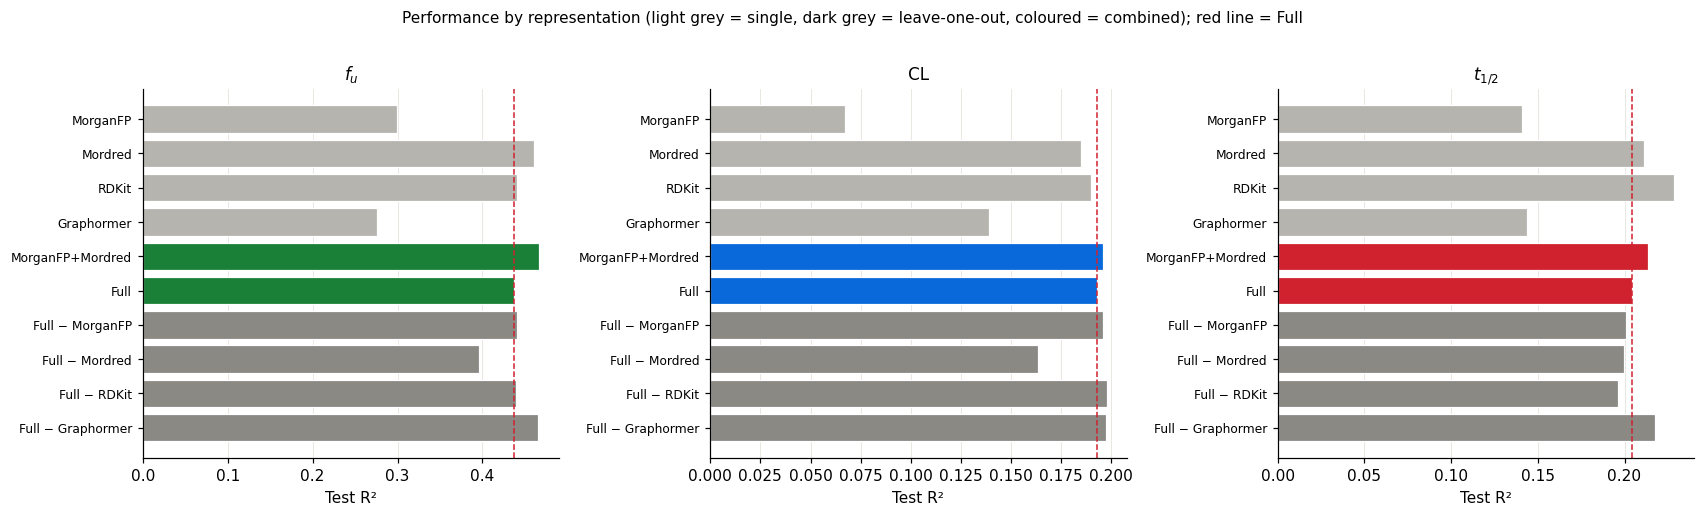

In [3]:
fig, axes = plt.subplots(1, len(done), figsize=(5.2 * len(done), 4.6), sharey=False)
for ax, prop in zip(np.atleast_1d(axes), done):
    g = runs[runs.property == prop].groupby('rep').r2.mean().reindex(avail)
    cols = ['#b5b4ae' if r in SOLO else ('#8a8984' if r in LOO else COLOR[prop]) for r in g.index]
    ax.barh(range(len(g)), g.values, color=cols, edgecolor='white', linewidth=0.8)
    ax.set_yticks(range(len(g)))
    ax.set_yticklabels(g.index, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Test R²')
    ax.set_title(LABEL[prop], fontsize=11)
    ax.grid(axis='y', visible=False)
    if 'Full' in g.index:
        ax.axvline(g['Full'], color='#cf222e', lw=1, ls='--')
fig.suptitle('Performance by representation (light grey = single, dark grey = leave-one-out, coloured = combined); red line = Full',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'representation_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Ablation — unique contribution of each representation

How much `Full − X` drops below `Full` is the unique contribution of X.

- **large drop** → it carries information no other representation can replace
- **almost no drop** → redundant or useless information
- **goes up instead** → that representation is **getting in the way**

,endpoint,removed,Full,Full − X,contribution (Full − (Full−X)),single performance
0,$f_u$,MorganFP,0.4372,0.4406,-0.0035,0.2995
1,$f_u$,Mordred,0.4372,0.3962,0.0410,0.4609
2,$f_u$,RDKit,0.4372,0.4399,-0.0027,0.4409
3,$f_u$,Graphormer,0.4372,0.4657,-0.0285,0.2763
4,CL,MorganFP,0.1928,0.1958,-0.0030,0.0671
5,CL,Mordred,0.1928,0.1634,0.0294,0.1851
6,CL,RDKit,0.1928,0.1977,-0.0049,0.1900
7,CL,Graphormer,0.1928,0.1975,-0.0047,0.1392
8,$t_{1/2}$,MorganFP,0.2044,0.2010,0.0033,0.1408
9,$t_{1/2}$,Mordred,0.2044,0.1995,0.0049,0.2112


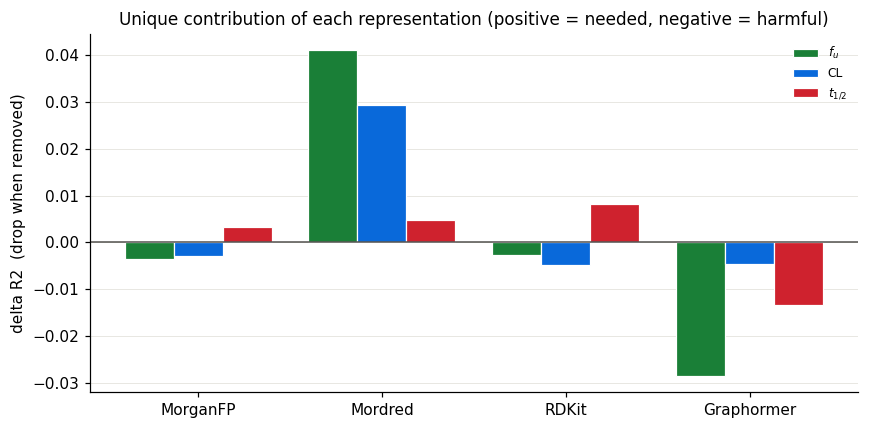

In [4]:
rows = []
for prop in done:
    g = runs[runs.property == prop].groupby('rep').r2.mean()
    if 'Full' not in g.index:
        continue
    for k in ALL4:
        loo = f'Full − {k}'
        if loo in g.index:
            rows.append({'endpoint': LABEL[prop], 'removed': k,
                         'Full': g['Full'], 'Full − X': g[loo],
                         'contribution (Full − (Full−X))': g['Full'] - g[loo],
                         'single performance': g.get(k, np.nan)})
abl = pd.DataFrame(rows)
display(abl.round(4))

if len(abl):
    fig, ax = plt.subplots(figsize=(8, 4))
    eps = abl.endpoint.unique()
    w, x = 0.8 / len(eps), np.arange(len(ALL4))
    for i, ep in enumerate(eps):
        q = abl[abl.endpoint == ep].set_index('removed').reindex(ALL4)
        c = [COLOR[p] for p in done if LABEL[p] == ep][0]
        ax.bar(x + (i - (len(eps) - 1) / 2) * w, q['contribution (Full − (Full−X))'],
               width=w, color=c, edgecolor='white', linewidth=0.8, label=ep)
    ax.axhline(0, color='#52514e', lw=1)
    ax.set_xticks(x); ax.set_xticklabels(ALL4)
    ax.set_ylabel('delta R2  (drop when removed)')
    ax.set_title('Unique contribution of each representation (positive = needed, negative = harmful)', fontsize=11)
    ax.legend(fontsize=8, frameon=False)
    ax.grid(axis='x', visible=False)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, 'representation_ablation.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 3. Check with four metrics

R² alone can be one-sided. Note that the error metrics (MAE, RMSE) are better when **lower**.

In [5]:
cols = [m for m, _, _ in METRICS if m in runs.columns]
full = runs.groupby(['property', 'rep'])[cols].mean()
view = full.reindex([(p, r) for p in done for r in avail])
view.columns = [n for m, n, _ in METRICS if m in cols]
view.round(4)

R²  Pearson r  Spearman ρ     MAE    RMSE
property  rep                                                             
fu        MorganFP           0.2995     0.5923      0.6188  0.6503  0.8191
          Mordred            0.4609     0.7188      0.7419  0.5430  0.7104
          RDKit              0.4409     0.7013      0.7204  0.5500  0.7254
          Graphormer         0.2763     0.5736      0.5818  0.6829  0.8309
          MorganFP+Mordred   0.4670     0.7226      0.7450  0.5383  0.7071
          Full               0.4372     0.7049      0.7256  0.5571  0.7254
          Full − MorganFP    0.4406     0.7061      0.7241  0.5573  0.7242
          Full − Mordred     0.3962     0.6751      0.6928  0.5884  0.7539
          Full − RDKit       0.4399     0.7051      0.7223  0.5622  0.7252
          Full − Graphormer  0.4657     0.7230      0.7473  0.5374  0.7068
clearance MorganFP           0.0671     0.3064      0.3615  0.7097  0.9620
          Mordred            0.1851     0.4323      0.4353  0.6681  0.8996
          RDKit              0.1900     0.4416      0.4740  0.6600  0.8964
          Graphormer         0.1392     0.3791      0.3953  0.6897  0.9249
          MorganFP+Mordred   0.1960     0.4449      0.4535  0.6615  0.8935
          Full               0.1928     0.4407      0.4579  0.6620  0.8953
          Full − MorganFP    0.1958     0.4440      0.4609  0.6622  0.8934
          Full − Mordred     0.1634     0.4096      0.4371  0.6725  0.9119
          Full − RDKit       0.1977     0.4470      0.4550  0.6601  0.8926
          Full − Graphormer  0.1975     0.4453      0.4560  0.6599  0.8925
half_life MorganFP           0.1408     0.4024      0.4302  0.7031  0.9196
          Mordred            0.2112     0.4727      0.5107  0.6548  0.8821
          RDKit              0.2286     0.4913      0.5298  0.6504  0.8699
          Graphormer         0.1437     0.3936      0.4138  0.7010  0.9191
          MorganFP+Mordred   0.2136     0.4759      0.5094  0.6562  0.8805
          Full               0.2044     0.4649      0.4963  0.6633  0.8856
          Full − MorganFP    0.2010     0.4608      0.4946  0.6647  0.8875
          Full − Mordred     0.1995     0.4588      0.4840  0.6716  0.8885
          Full − RDKit       0.1962     0.4551      0.4834  0.6699  0.8906
          Full − Graphormer  0.2177     0.4799      0.5146  0.6534  0.8780

## 4. Implications for this study's choice of representation

The main experiments (01–14) used **Graphormer embeddings**. Check where Graphormer stands in this ablation,
and judge whether the DA conclusions depend on the representation together with the RDKit re-run in `14_proposed_methods`.

In [6]:
if 'Full' in runs.rep.unique():
    g = runs.groupby(['property', 'rep']).r2.mean()
    rows = []
    for prop in done:
        best_rep = g.loc[prop].idxmax()
        rows.append({'endpoint': LABEL[prop],
                     'Graphormer alone': g.loc[(prop, 'Graphormer')] if (prop, 'Graphormer') in g.index else np.nan,
                     'best representation': best_rep, 'best R²': g.loc[prop].max(),
                     'Full': g.loc[(prop, 'Full')] if (prop, 'Full') in g.index else np.nan})
    display(pd.DataFrame(rows).round(4))
print('''
How to read
- If Graphormer alone is far below the best representation, the main experiment's absolute performance was limited by the representation.
- However, when the DA experiments were repeated with RDKit descriptors in `14_proposed_methods`,
  the per-endpoint transfer pattern held. In other words, **absolute performance depends on the representation, but the conclusions about transfer do not**.
''')

,endpoint,Graphormer alone,best representation,best R²,Full
0,$f_u$,0.2763,MorganFP+Mordred,0.4670,0.4372
1,CL,0.1392,Full − RDKit,0.1977,0.1928
2,$t_{1/2}$,0.1437,RDKit,0.2286,0.2044



How to read
- If Graphormer alone is far below the best representation, the main experiment's absolute performance was limited by the representation.
- However, when the DA experiments were repeated with RDKit descriptors in `14_proposed_methods`,
  the per-endpoint transfer pattern held. In other words, **absolute performance depends on the representation, but the conclusions about transfer do not**.



## 5. Caveats for interpretation

1. **No hyperparameter tuning** — conventional defaults. Tuning per representation could change the ranking, so
   read this only as "a relative comparison under this setting".
2. **Very different dimensionalities** — MorganFP 2048, Mordred 1445, RDKit 203, Graphormer 768.
   Tree models are fairly insensitive to dimensionality, but higher dimensions offer more split candidates, which can help.
3. **Mordred and RDKit overlap in information** — both are physicochemical descriptors. Even if each one's
   leave-one-out contribution is small, removing both could cause a large drop (they substitute for each other).
4. **Descriptor scaling** — Mordred and RDKit contain values around 10³⁰, so they were scaled by quantiles (1–99%) and
   clipped to ±5. Using mean and standard deviation overflows into NaN.
5. **This is a target-only setting** — the source is not used. For interaction with DA/transfer see `14_proposed_methods`.